In [1]:
!pip install pandas numpy matplotlib requests fredapi statsmodels xlrd yfinance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
print('Libraries have now been successfully loaded on')
#importing all the libraries needed for the project

Libraries have now been successfully loaded on


In [3]:
from fredapi import Fred
from config import FRED_API_KEY, EIA_API_KEY
# Pasting my API key 
fred = Fred(api_key=FRED_API_KEY)

# Pull Henry Hub Natural Gas Spot Price
# MHHNGSP = Monthly Henry Hub Natural Gas Spot Price
henry_hub = fred.get_series('MHHNGSP', observation_start='2000-01-01')

# Convert to a DataFrame and name the column
df = henry_hub.to_frame(name='price_usd_mmbtu')

print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")

            price_usd_mmbtu
2000-01-01             2.42
2000-02-01             2.66
2000-03-01             2.79
2000-04-01             3.04
2000-05-01             3.59
2000-06-01             4.29
2000-07-01             3.99
2000-08-01             4.43
2000-09-01             5.06
2000-10-01             5.02

Shape: (318, 1)
Date range: 2000-01-01 00:00:00 to 2026-06-01 00:00:00


In [4]:
# Check to find and clean missing values
print("Missing values:", df['price_usd_mmbtu'].isna().sum())

# Drop any missing rows
df = df.dropna()

# Make sure dates are in order
df = df.sort_index()

print(f"\nClean dataset: {len(df)} monthly observations")
print(df.tail(5))

Missing values: 0

Clean dataset: 318 monthly observations
            price_usd_mmbtu
2026-02-01             3.62
2026-03-01             3.04
2026-04-01             2.77
2026-05-01             2.94
2026-06-01             3.15


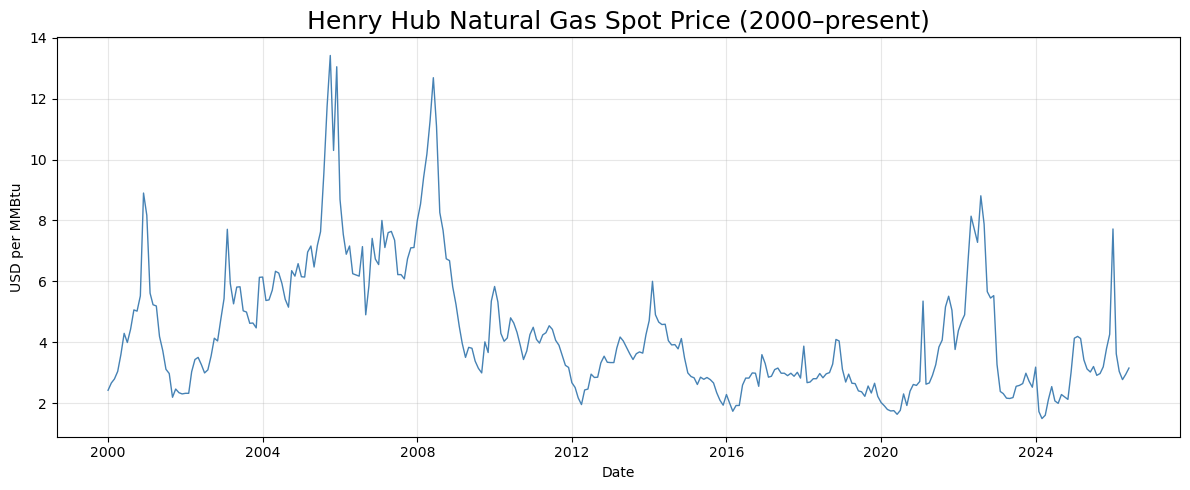

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df['price_usd_mmbtu'], color='steelblue', linewidth=1)

ax.set_title('Henry Hub Natural Gas Spot Price (2000–present)', fontsize=18)
ax.set_xlabel('Date')
ax.set_ylabel('USD per MMBtu')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Compute log returns
df['log_return'] = np.log(df['price_usd_mmbtu'] / df['price_usd_mmbtu'].shift(1))

# Drop the first row which will be NaN (no previous price to compare)
df_returns = df.dropna()

print(df_returns[['price_usd_mmbtu', 'log_return']].head(10))

            price_usd_mmbtu  log_return
2000-02-01             2.66    0.094559
2000-03-01             2.79    0.047715
2000-04-01             3.04    0.085816
2000-05-01             3.59    0.166295
2000-06-01             4.29    0.178135
2000-07-01             3.99   -0.072496
2000-08-01             4.43    0.104608
2000-09-01             5.06    0.132967
2000-10-01             5.02   -0.007937
2000-11-01             5.52    0.094948


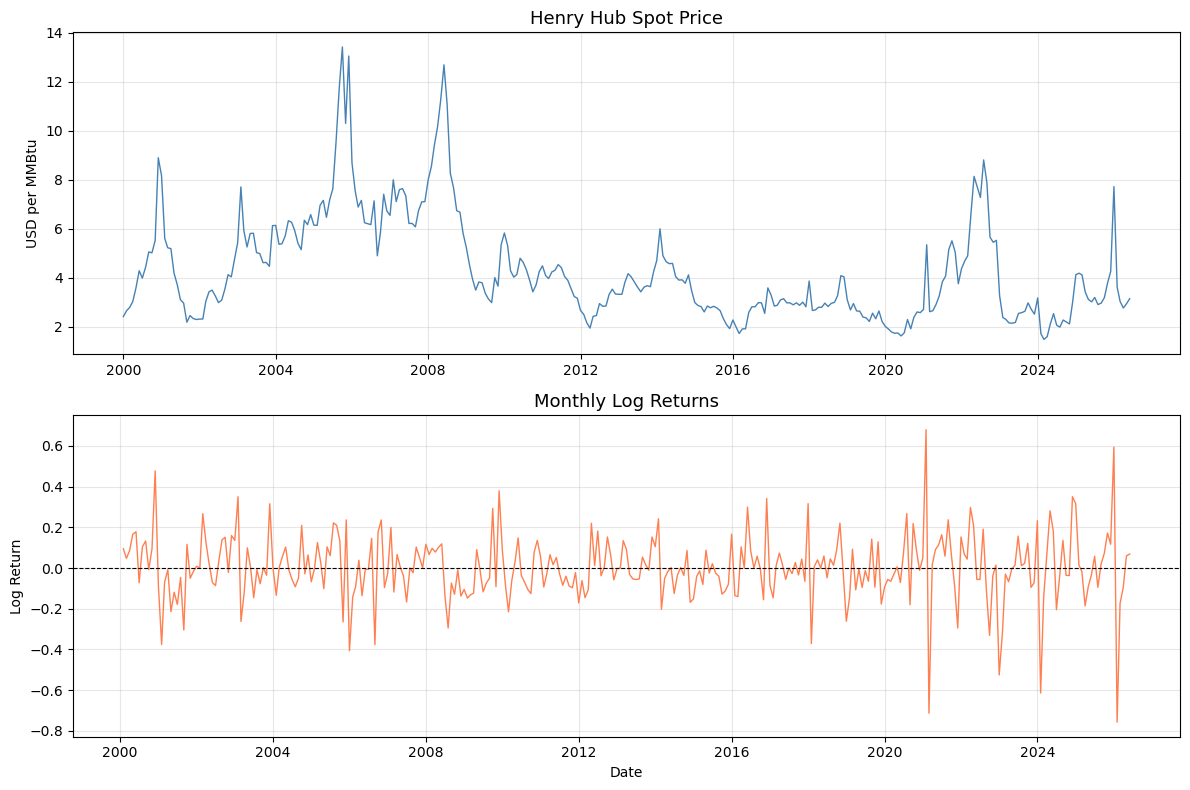

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top chart: price
axes[0].plot(df.index, df['price_usd_mmbtu'], color='steelblue', linewidth=1)
axes[0].set_title('Henry Hub Spot Price', fontsize=13)
axes[0].set_ylabel('USD per MMBtu')
axes[0].grid(True, alpha=0.3)

# Bottom chart: log returns
axes[1].plot(df_returns.index, df_returns['log_return'], color='coral', linewidth=1)
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Monthly Log Returns', fontsize=13)
axes[1].set_ylabel('Log Return')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
stats = df_returns['log_return'].describe()

# Add skewness and kurtosis manually as describe() doesn't include them
skewness = df_returns['log_return'].skew()
kurtosis = df_returns['log_return'].kurtosis()

print("=== Descriptive Statistics: Log Returns ===")
print(stats)
print(f"\nSkewness:  {skewness:.4f}")
print(f"Kurtosis:  {kurtosis:.4f}")
print(f"\nAnnualised volatility: {df_returns['log_return'].std() * np.sqrt(12):.4f}")

=== Descriptive Statistics: Log Returns ===
count    317.000000
mean       0.000832
std        0.162574
min       -0.757340
25%       -0.084230
50%       -0.003781
75%        0.088057
max        0.680148
Name: log_return, dtype: float64

Skewness:  -0.3460
Kurtosis:  4.1771

Annualised volatility: 0.5632


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_returns['log_return'], bins=40, color='steelblue', 
        edgecolor='white', linewidth=0.5, density=True, alpha=0.8)

# Overlay a normal distribution for comparison
from scipy import stats as scipy_stats
x = np.linspace(df_returns['log_return'].min(), df_returns['log_return'].max(), 200)
normal_pdf = scipy_stats.norm.pdf(x, df_returns['log_return'].mean(), 
                                   df_returns['log_return'].std())
ax.plot(x, normal_pdf, color='coral', linewidth=2, label='Normal distribution')

ax.set_title('Distribution of Monthly Log Returns vs Normal', fontsize=13)
ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df_returns['log_return'], lags=24, ax=ax)
ax.set_title('Autocorrelation of Monthly Log Returns')
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['price_usd_mmbtu'].dropna())

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

In [ ]:
from config import FRED_API_KEY, EIA_API_KEY
url3 = (
    f'https://api.eia.gov/v2/natural-gas/stor/wkly/data/'
    f'?api_key={EIA_API_KEY}'
    f'&frequency=weekly'
    f'&data[0]=value'
    f'&facets[duoarea][]=R48'
    f'&facets[process][]=SWO'
    f'&start=2000-01-01'
    f'&sort[0][column]=period'
    f'&sort[0][direction]=asc'
    f'&length=2000'
)

response3 = requests.get(url3)
data3 = response3.json()

storage_df = pd.DataFrame(data3['response']['data'])
storage_df['period'] = pd.to_datetime(storage_df['period'])
storage_df = storage_df.set_index('period')
storage_df = storage_df[['value']].rename(columns={'value': 'storage_bcf'})
storage_df['storage_bcf'] = pd.to_numeric(storage_df['storage_bcf'], errors='coerce')
storage_df = storage_df.dropna().sort_index()

print(storage_df.head(10))
print(f"Shape: {storage_df.shape}")
print(f"Date range: {storage_df.index[0]} to {storage_df.index[-1]}")

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Top: Henry Hub price
axes[0].plot(df.index, df['price_usd_mmbtu'], color='steelblue', linewidth=1)
axes[0].set_title('Henry Hub Spot Price', fontsize=13)
axes[0].set_ylabel('USD per MMBtu')
axes[0].grid(True, alpha=0.3)

# Bottom: Storage
axes[1].plot(storage_df.index, storage_df['storage_bcf'], color='coral', linewidth=1)
axes[1].set_title('US Natural Gas Working Storage (Lower 48)', fontsize=13)
axes[1].set_ylabel('Billion Cubic Feet (Bcf)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Add month column to your price dataframe
df['month'] = df.index.month

# Average price by calendar month across all years
monthly_avg = df.groupby('month')['price_usd_mmbtu'].mean()

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(month_names, monthly_avg.values, color='steelblue', 
       edgecolor='white', linewidth=0.5)
ax.set_title('Average Henry Hub Price by Calendar Month (2000–present)', fontsize=13)
ax.set_ylabel('Average Price (USD per MMBtu)')
ax.set_xlabel('Month')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
#calculate mean to find mu
print(f"Mean price: {df['price_usd_mmbtu'].mean():.4f}")
print(f"Median price: {df['price_usd_mmbtu'].median():.4f}")

In [ ]:
#Phase 2 Building the model for Means Reverting using Euler-Maruyama Scheme as an approximation for SDE

In [ ]:
import numpy as np

def simulate_ou(mu, kappa, sigma, P0, T, dt, n_paths):
    """
    Simulate price paths using Euler-Maruyama discretisation
    of the Ornstein-Uhlenbeck process.
    
    Parameters:
    mu     : long-run mean price
    kappa  : mean reversion speed
    sigma  : volatility
    P0     : starting price
    T      : total time in years
    dt     : time step in years
    n_paths: number of simulated paths
    """
    n_steps = int(T / dt)
    paths = np.zeros((n_steps + 1, n_paths))
    paths[0] = P0
    
    for t in range(1, n_steps + 1):
        Z = np.random.standard_normal(n_paths)
        paths[t] = (paths[t-1] 
                   + kappa * (mu - paths[t-1]) * dt 
                   + sigma * np.sqrt(dt) * Z)
    
    return paths

def simulate_schwartz(mu_log, kappa, sigma, P0, T, dt, n_paths):
    """
    Simulate the Schwartz one-factor model correctly in log price space.
    Calibrated parameters describe log price dynamics, so we simulate
    log prices via OU and exponentiate to recover price paths.
    Guarantees positive prices by construction.
    """
    log_P0 = np.log(P0)
    log_paths = simulate_ou(mu_log, kappa, sigma, log_P0, T, dt, n_paths)
    return np.exp(log_paths)


# Using  our Phase 1 estimates as starting parameters
mu    = 4.23    # long-run mean (USD/MMBtu)
kappa = 0.5    # placeholder — we'll calibrate this properly next
sigma = 0.56    # annualised volatility from Phase 1
P0    = df['price_usd_mmbtu'].iloc[-1]  # start from most recent price
T     = 5       # simulate 5 years forward
dt    = 1/12    # monthly time steps

# Run simulation
np.random.seed(42)  # for reproducibility
paths = simulate_ou(mu, kappa, sigma, P0, T, dt, n_paths=100)

print(f"Simulation shape: {paths.shape}")
print(f"Starting price: ${P0:.2f}")
print(f"Time steps: {int(T/dt)} months")

In [ ]:
time_axis = np.linspace(0, T, int(T/dt) + 1)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot all simulated paths in light blue
for i in range(100):
    ax.plot(time_axis, paths[:, i], color='steelblue', 
            linewidth=0.5, alpha=0.3)

# Plot the mean path across all simulations
ax.plot(time_axis, paths.mean(axis=1), color='red', 
        linewidth=2, label='Mean path')

# Plot the long-run mean as a reference line
ax.axhline(y=mu, color='black', linewidth=1.5, 
           linestyle='--', label=f'Long-run mean (μ = ${mu})')

ax.set_title('Ornstein-Uhlenbeck Simulated Price Paths (100 scenarios)', fontsize=13)
ax.set_xlabel('Years')
ax.set_ylabel('Price (USD per MMBtu)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('simulated_paths.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from scipy.optimize import minimize
from scipy.stats import norm

# Work in log price space
log_prices = np.log(df['price_usd_mmbtu'].dropna().values)
dt = 1/12

def ou_log_likelihood(params, log_prices, dt):
    kappa, mu_log, sigma = params
    if kappa <= 0 or sigma <= 0:
        return 1e10

    P_current = log_prices[:-1]
    P_next    = log_prices[1:]

    # Exact OU transition density (not Euler approximation)
    exp_k     = np.exp(-kappa * dt)
    cond_mean = P_current * exp_k + mu_log * (1 - exp_k)
    cond_var  = (sigma**2 / (2 * kappa)) * (1 - np.exp(-2 * kappa * dt))

    log_lik = norm.logpdf(P_next, loc=cond_mean, scale=np.sqrt(cond_var))
    return -np.sum(log_lik)

initial_params = [0.5, np.log(4.23), 0.56]
bounds = [(0.01, 10), (0.0, 5.0), (0.01, 2.0)]

result = minimize(
    ou_log_likelihood,
    initial_params,
    args=(log_prices, dt),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 10000}
)

kappa_fit, mu_log_fit, sigma_fit = result.x

# Convert mu back from log space to price space
mu_fit = np.exp(mu_log_fit)

print("=== Calibrated Parameters ===")
print(f"κ (mean reversion speed): {kappa_fit:.4f}")
print(f"μ (long-run mean):        ${mu_fit:.4f}")
print(f"σ (volatility):           {sigma_fit:.4f}")
print(f"Optimisation success:     {result.success}")

In [ ]:
# Resimulate using calibrated parameters
np.random.seed(42)



paths_calibrated = simulate_schwartz(
    mu_log  = mu_log_fit,
    kappa   = kappa_fit,
    sigma   = sigma_fit,
    P0      = df['price_usd_mmbtu'].iloc[-1],
    T       = 5,
    dt      = 1/12,
    n_paths = 100
)

time_axis = np.linspace(0, 5, int(5/(1/12)) + 1)

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(100):
    ax.plot(time_axis, paths_calibrated[:, i], 
            color='steelblue', linewidth=0.5, alpha=0.3)

ax.plot(time_axis, paths_calibrated.mean(axis=1), 
        color='red', linewidth=2, label='Mean path')

ax.axhline(y=mu_fit, color='black', linewidth=1.5,
           linestyle='--', label=f'Long-run mean (μ = ${mu_fit:.2f})')

ax.set_title('OU Simulated Paths — Calibrated Parameters', fontsize=13)
ax.set_xlabel('Years')
ax.set_ylabel('Price (USD per MMBtu)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('simulated_paths.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Compare simulated vs historical statistics
sim_final_prices = paths_calibrated[-1, :]
sim_returns = np.diff(np.log(paths_calibrated), axis=0).flatten()
hist_returns = df_returns['log_return'].values

print("=== Model Validation ===")
print(f"{'Metric':<25} {'Historical':>12} {'Simulated':>12}")
print("-" * 50)
print(f"{'Mean log return':<25} {hist_returns.mean():>12.4f} {sim_returns.mean():>12.4f}")
print(f"{'Std log return':<25} {hist_returns.std():>12.4f} {sim_returns.std():>12.4f}")
print(f"{'Skewness':<25} {pd.Series(hist_returns).skew():>12.4f} {pd.Series(sim_returns).skew():>12.4f}")
print(f"{'Kurtosis':<25} {pd.Series(hist_returns).kurtosis():>12.4f} {pd.Series(sim_returns).kurtosis():>12.4f}")
print(f"{'Min price (5yr)':<25} {'N/A':>12} {sim_final_prices.min():>12.4f}")
print(f"{'Max price (5yr)':<25} {'N/A':>12} {sim_final_prices.max():>12.4f}")

In [ ]:
#Phase 3

In [ ]:
def monte_carlo_option(mu_log, kappa, sigma, P0, K, T, r, dt, n_paths):
    """
    Price a European call option using Monte Carlo simulation
    under the Schwartz one-factor model (log price space).

    mu_log  : long-run mean in log price space
    kappa   : mean reversion speed
    sigma   : volatility in log price space
    P0      : current price
    K       : strike price
    T       : time to expiry in years
    r       : risk-free rate
    dt      : time step in years
    n_paths : number of simulated paths
    """
    # Simulate price paths in log space, exponentiate to get prices
    paths = simulate_schwartz(mu_log, kappa, sigma, P0, T, dt, n_paths)

    # Extract prices at expiry (final row)
    prices_at_expiry = paths[-1, :]

    # Compute call option payoffs
    payoffs = np.maximum(prices_at_expiry - K, 0)

    # Discount back to today
    option_price = np.exp(-r * T) * np.mean(payoffs)

    # Fraction of paths ending in the money
    in_the_money = np.mean(prices_at_expiry > K)

    return option_price, payoffs, prices_at_expiry, in_the_money

# Parameters
P0    = df['price_usd_mmbtu'].iloc[-1]  # current price
K     = 5.00                             # strike price
T     = 1.0                             # 1 year to expiry
r     = 0.05                            # risk-free rate (5%)
dt    = 1/12                            # monthly steps
n_paths = 10000                         # more paths = more accurate

np.random.seed(42)
option_price, payoffs, prices_at_expiry, itm = monte_carlo_option(
    mu_log_fit, kappa_fit, sigma_fit, P0, K, T, r, dt, n_paths
)

print(f"Current price:        ${P0:.2f}")
print(f"Strike price:         ${K:.2f}")
print(f"Time to expiry:       {T} year")
print(f"Risk-free rate:       {r*100:.1f}%")
print(f"\nOption price:         ${option_price:.4f} per MMBtu")
print(f"Paths in the money:   {itm*100:.1f}%")
print(f"Average payoff:       ${np.mean(payoffs):.4f}")

In [ ]:
strikes = [3.00, 3.50, 4.00, 4.50, 5.00]

print(f"Current price: ${df['price_usd_mmbtu'].iloc[-1]:.2f}")
print(f"\n{'Strike':>8} {'Option Price':>14} {'In the Money':>14}")
print("-" * 40)

np.random.seed(42)
for K in strikes:
    price, _, _, itm = monte_carlo_option(
        mu_log_fit, kappa_fit, sigma_fit,
        df['price_usd_mmbtu'].iloc[-1],
        K, 1.0, 0.05, 1/12, n_paths=10000
    )
    print(f"${K:>6.2f} {price:>13.4f} {itm*100:>13.1f}%")

In [ ]:
strikes = np.arange(2.50, 6.50, 0.25)
expiries = [0.25, 0.5, 1.0, 2.0]
colors = ['steelblue', 'coral', 'green', 'purple']

fig, ax = plt.subplots(figsize=(12, 6))

np.random.seed(42)
for T_exp, color in zip(expiries, colors):
    prices = []
    for K in strikes:
        p, _, _, _ = monte_carlo_option(
            mu_log_fit, kappa_fit, sigma_fit,
            df['price_usd_mmbtu'].iloc[-1],
            K, T_exp, 0.05, 1/12, n_paths=5000
        )
        prices.append(p)
    ax.plot(strikes, prices, color=color,
            linewidth=2, label=f'T = {T_exp} years')

ax.axvline(x=df['price_usd_mmbtu'].iloc[-1], color='black', linewidth=1.5,
           linestyle='--', label=f'Current price (${df["price_usd_mmbtu"].iloc[-1]:.2f})')
ax.axvline(x=mu_fit, color='gray', linewidth=1.5,
           linestyle=':', label=f'Long-run mean (${mu_fit:.2f})')

ax.set_title('European Call Option Price Surface\nSchwartz One-Factor Model', fontsize=13)
ax.set_xlabel('Strike Price (USD per MMBtu)')
ax.set_ylabel('Option Price (USD per MMBtu)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('option_price_surface.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
#Phase 4

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pull front-month and next-month natural gas futures
# NG=F is the front-month NYMEX natural gas futures contract
ng_front = yf.download('NG=F', start='2010-01-01', progress=False)
ng_front = ng_front['Close'].resample('MS').last()
ng_front.name = 'front_month'

print(f"Front-month futures shape: {ng_front.shape}")
print(f"Date range: {ng_front.index[0]} to {ng_front.index[-1]}")
print(f"\nMost recent 5 observations:")
print(ng_front.tail())

In [ ]:
# Merge spot and futures prices
ng_front = yf.download('NG=F', start='2010-01-01', progress=False)
ng_front = ng_front['Close'].resample('MS').last()

# Add this line to flatten from (199,1) to (199,)
ng_front = ng_front.squeeze()
ng_front.name = 'front_month'

print(f"Front-month futures shape: {ng_front.shape}")
print(ng_front.tail())

spot = df['price_usd_mmbtu'].resample('MS').last()
spot.name = 'spot'

# Align both series on common dates
combined = pd.DataFrame({'spot': spot, 'futures': ng_front}).dropna()

print(f"Combined shape: {combined.shape}")
print(f"Date range: {combined.index[0]} to {combined.index[-1]}")
print(f"\nMost recent 5 observations:")
print(combined.tail())

In [ ]:
# Parameters for convenience yield calculation
r = 0.05   # risk-free rate (5%)
c = 0.02   # storage cost (2% per year, typical for natural gas)
T = 1/12   # one month forward

# Compute implied convenience yield from cost-of-carry formula
# cy = r + c - (1/T) * ln(F/S)
combined['cy'] = (r + c 
                  - (1/T) * np.log(combined['futures'] / combined['spot']))

# Add month column for seasonality analysis
combined['month'] = combined.index.month

print(combined[['spot', 'futures', 'cy']].tail(10))
print(f"\nMean convenience yield: {combined['cy'].mean():.4f}")
print(f"Max convenience yield:  {combined['cy'].max():.4f}")
print(f"Min convenience yield:  {combined['cy'].min():.4f}")

In [ ]:
# Merge convenience yield with storage data
# Resample storage to monthly
storage_monthly = storage_df['storage_bcf'].resample('MS').mean()

# Combine
phase4 = pd.DataFrame({
    'cy': combined['cy'],
    'storage': storage_monthly
}).dropna()

print(f"Combined shape: {phase4.shape}")
print(phase4.tail())

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Chart 1 — Convenience yield over time
axes[0].plot(phase4.index, phase4['cy'], 
             color='steelblue', linewidth=1)
axes[0].axhline(y=0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Implied Convenience Yield Over Time', fontsize=12)
axes[0].set_ylabel('Convenience Yield')
axes[0].grid(True, alpha=0.3)

# Chart 2 — Storage over time
axes[1].plot(phase4.index, phase4['storage'], 
             color='coral', linewidth=1)
axes[1].set_title('Natural Gas Storage Levels (Lower 48 States)', fontsize=12)
axes[1].set_ylabel('Storage (Bcf)')
axes[1].grid(True, alpha=0.3)

# Chart 3 — Scatter: storage vs convenience yield
axes[2].scatter(phase4['storage'], phase4['cy'], 
                alpha=0.4, color='steelblue', s=20)
axes[2].axhline(y=0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Storage Level vs Convenience Yield', fontsize=12)
axes[2].set_xlabel('Storage (Bcf)')
axes[2].set_ylabel('Convenience Yield')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Phase 4 — Convenience Yield & Storage Analysis\n'
             'Schwartz One-Factor Model', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('convenience_yield_storage.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(f"K:  {K}")
print(f"T:  {T}")
print(f"r:  {r}")

np.random.seed(42)
test_price, _, test_expiry, test_itm = monte_carlo_option(
    mu_log_fit, kappa_fit, sigma_fit, 
    df['price_usd_mmbtu'].iloc[-1], 
    5.00,  # strike hardcoded
    1.0,   # expiry hardcoded
    0.05,  # rate hardcoded
    1/12, 
    10000
)
print(f"\nOption price: ${test_price:.4f}")
print(f"ITM: {test_itm*100:.1f}%")
print(f"\nSample expiry prices: {test_expiry[:10].round(2)}")